This is an example notebook to show how to calculate a minimal, sufficient, explanation for a ladybird. 

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch as tt
from torchvision.models import get_model, get_weight
from rex_xai.lib import ReX

In [5]:
# get model and weights
model = get_model("mobilenet_v3_small", weights="DEFAULT")
weights = get_weight("MobileNet_V3_Small_Weights.IMAGENET1K_V1")

# set the device, either 'mps', 'cuda' or 'cpu'. 'cpu' will work, but will be slow
device = tt.device('mps')

model.eval().to(device)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [6]:
model_shape = ["N", 3, 224, 224]

In [7]:
rex = ReX(model, model_shape, device, 'RGB')

In [8]:
img = rex.set_rgb_image('../tests/test_data/ladybird.jpg')

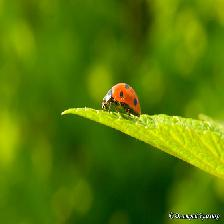

In [9]:
img

In [10]:
print(weights.transforms())

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [11]:
# for correct overlay of explanation, we need to reshape the original image a bit
from torchvision import transforms as T
input = T.functional.center_crop(img, 256)
input = T.functional.resize(input, (224, 224))
rex.data.input = input


In [12]:
rex.set_transformed_data(weights.transforms()(img).unsqueeze(0).to(device))

In [13]:
print(rex.data.input.size)

(224, 224)


In [14]:
print(rex.data.data.shape)

torch.Size([1, 3, 224, 224])


In [17]:
rex.set_target().show_target()

FOUND_CLASS: 301, FOUND_CONF: 0.60946, TARGET_CLASS: n/a, TARGET_CONFIDENCE: n/a


In [18]:
rex.args.minimum_confidence_threshold = 0.5
rex.args.batch_size = 64 # this works well on mps
rex.args.seed = 0  # for reproducibility

In [19]:
_ = rex.calculate_responsibility().generate_explanation_object()

100%|██████████| 20/20 [00:00<00:00, 30.95it/s]


In [20]:
print(rex.stats)

{'total_passing': 590, 'total_failing': 1174, 'max_depth_reached': 9, 'avg_box_size': 1577.7770833333332}


In [21]:
rex.extract_sufficient_explanation()

Extracting global explanation:   1%|▏         | 64/5017 [00:00<00:05, 956.87it/s]


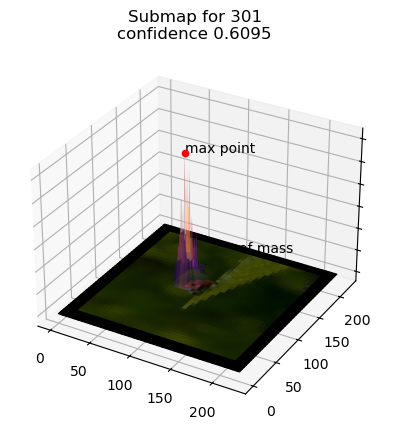

In [22]:
rex.explanation.surface_plot()

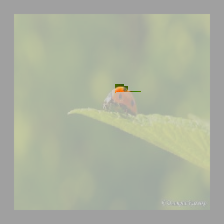

In [23]:
rex.show()

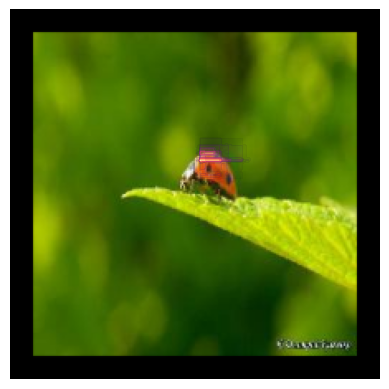

In [24]:
rex.explanation.heatmap_plot()

In [25]:
rex.extract_contrastive_explanation()

Calculating Contrastive Explanation:   8%|▊         | 64/784 [00:00<00:00, 1943.62it/s]


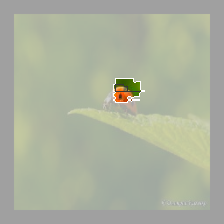

In [26]:
rex.show()

In [27]:
rex.extract_complete_explanation()

Calculating Contrastive Explanation:   8%|▊         | 64/784 [00:00<00:03, 228.51it/s]


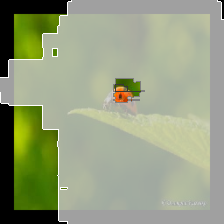

In [28]:
rex.show()